In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re

In [108]:
df = pd.read_excel("data/par-to-par-2.xlsx")

for col in ["DATE_FROM", "DATE_TO"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()

,CELEX_FROM,TITLE_FROM,NUMBER_FROM,DATE_FROM,TEXT_FROM,CELEX_TO,TITLE_TO,NUMBER_TO,TEXT_TO,DATE_TO
0,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,18,1989-02-28,18 Those arguments need not be addressed . As ...,61976CJ0030,Berthold Küster v European Parliament.,8,8 IT CANNOT BE CONTESTED THAT THOSE TO WHOM A ...,1976-11-25
1,61985CJ0341,Erik van der Stijl and Geoffrey Cullington v C...,51,1989-02-28,51 The Court held in its judgment of 30 Octobe...,61973CJ0188,Daniele Grassi v Council of the European Commu...,38,"38 IN FACT, THOUGH THE APPOINTING AUTHORITY HA...",1974-10-30
2,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,16,1991-07-03,"16 In that respect it should be observed that,...",61982CJ0043,Vereniging ter Bevordering van het Vlaamse Boe...,25,25 IN THAT CONNECTION IT MUST BE OBSERVED THAT...,1984-01-17
3,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,51,1991-07-03,51 In its judgment in Case 31/80 L' Oréal v De...,61980CJ0031,"NV L'Oréal and SA L'Oréal v PVBA ""De Nieuwe AM...",25,25 AS THE COURT EMPHASIZED IN ITS JUDGMENT OF ...,1980-12-11
4,61986CJ0062,AKZO Chemie BV v Commission of the European Co...,60,1991-07-03,60 With regard to market shares the Court has ...,61976CJ0085,Hoffmann-La Roche & Co. AG v Commission of the...,41,41FURTHERMORE ALTHOUGH THE IMPORTANCE OF THE M...,1979-02-13


In [109]:
count_before = len(df)

# Remove rows with missing values
df = df.dropna()
print(f"Removed {count_before - len(df)} rows with missing values")

count_before = len(df)

# Remove duplicates
df = df.drop_duplicates()
print(f"Removed {count_before - len(df)} duplicates")

Removed 400 rows with missing values
Removed 0 duplicates


In [110]:
# Remove those with length above 32767 (max int value)
df = df[df["TEXT_FROM"].str.len() < 32767]
df = df[df["TEXT_TO"].str.len() < 32767]
df = df[df["TITLE_FROM"].str.len() < 32767]
df = df[df["TITLE_TO"].str.len() < 32767]

In [111]:
def remove_paragraph_numbers(text: str) -> str:
    return re.sub(r'^\s*\d+[\.\)]?\s*', '', text)

df["TEXT_FROM"] = df["TEXT_FROM"].apply(remove_paragraph_numbers)
df["TEXT_TO"] = df["TEXT_TO"].apply(remove_paragraph_numbers)

In [112]:
# Remove quoted text from TEXT_FROM and TEXT_TO
# To avoid direct quotes from the citation
# Does however also remove quotes from articles and directives
df["TEXT_FROM"] = df["TEXT_FROM"].str.replace(r'"[^"]*"', '<QUOTED_TEXT>', regex=True)
df["TEXT_TO"] = df["TEXT_TO"].str.replace(r'"[^"]*"', '<QUOTED_TEXT>', regex=True)

In [113]:
months = (
    r"(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|"
    r"Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:t(?:ember)?)?|"
    r"Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)"
)

date_patterns_raw = [
    # Numeric dates (DD/MM/YYYY, MM-DD-YYYY, YYYY/MM/DD, etc.)
    r"\b\d{1,2}[./\-\s]\d{1,2}[./\-\s](?:19|20)\d{2}\b",        # 12/05/2020, 12-05-2020, 12.05.2020
    r"\b(?:19|20)\d{2}[./\-\s]\d{1,2}[./\-\s]\d{1,2}\b",        # 2020-05-12, 2020/5/12

    # Month name + day + year (comma usually present; allow optional)
    rf"\b{months}\s+\d{{1,2}}(?:st|nd|rd|th)?\,?\s+(?:19|20)\d{{2}}\b",  # March 3, 2021 / March 3 2021

    # Day + month name + year (comma optional)
    rf"\b\d{{1,2}}(?:st|nd|rd|th)?\s+{months}\,?\s*(?:19|20)\d{{2}}\b",  # 3 March 2021 / 3rd March, 2021

    # Year + month name + day
    rf"\b(?:19|20)\d{{2}}\s+{months}\s+\d{{1,2}}(?:st|nd|rd|th)?\b",     # 2021 March 3

    # Standalone year
    r"\b(?:19|20)\d{2}\b"
]

# Compile with IGNORECASE to match 'march'/'MARCH' etc.
date_patterns = [re.compile(p, re.IGNORECASE) for p in date_patterns_raw]

def remove_dates(text: str) -> str:
    for pattern in date_patterns:
        text = re.sub(pattern, '<DATE>', text)
    return text.strip()

# Remove from TEXT_FROM and TEXT_TO
df["TEXT_FROM"] = df["TEXT_FROM"].apply(remove_dates)
df["TEXT_TO"] = df["TEXT_TO"].apply(remove_dates)

In [114]:
DASH = r"[-\u2013\u2014\u2212]"                        # -, –, —, −
COURT = rf"(?:[CTF]\s*{DASH}?\s*)?"                    # optional C-/T-/F-
YEAR  = r"\d{2,4}"
CASE_NUMBER = rf"\d+/{YEAR}(?:\s*[A-Z]{{1,4}})?"       # 347/88, 131/12 P, 404/15 PPU

# Sub-patterns (kept equivalent to your originals)
_case_joined_all = (
    rf"\bJoined Cases?\s+(?:{COURT}{CASE_NUMBER}"
    rf"(?:\s*(?:,|and|&)\s*{COURT}{CASE_NUMBER})+)"
    r"[^.,;)]*"
)
_case_joined_trailing_year = (
    rf"\bJoined Cases?\s+(?:{COURT}\d+(?:\s*(?:,|and|&)\s*{COURT}\d+)+\s*/\s*{YEAR})"
    r"[^.,;)]*"
)
_case_joined_range = (
    rf"\bJoined Cases?\s+(?:{COURT}\d+\s*(?:{DASH}|to|through)\s*{COURT}\d+/\s*{YEAR})"
    r"[^.,;)]*"
)
_case_single = rf"\bCase\s+{COURT}{CASE_NUMBER}[^.,;)]*"

_ecr = r"\bECR\s+(?:[IVX]+[-\u2013\u2014\u2212]?\d{1,5}|\d{1,5})\b"

_para = (
    r"\bpara(?:graph)?s?\.?\s+\d+"
    r"(?:\s*(?:[-\u2013\u2014\u2212]|to|through)\s*\d+)?"
    r"(?:\s*,\s*\d+)*"
    r"(?:\s*(?:and|&)\s*\d+)?\b"
)

# One master regex with named groups -> one pass over the text
_MASTER = re.compile(
    rf"(?P<CASE>{_case_joined_all}|{_case_joined_trailing_year}|{_case_joined_range}|{_case_single})"
    rf"|(?P<ECR>{_ecr})"
    rf"|(?P<PARAGRAPH>{_para})",
    flags=re.IGNORECASE,
)

def _repl(m: re.Match) -> str:
    g = m.lastgroup
    if g == "CASE":
        return "<CASE>"
    if g == "ECR":
        return "<ECR>"
    return "<PARAGRAPH>"

def remove_citations(text):
    if not isinstance(text, str):
        return text
    return _MASTER.sub(_repl, text).strip()

# Apply (apply/map are similar here; this keeps non-strings untouched)
df["TEXT_FROM"] = df["TEXT_FROM"].apply(remove_citations)
df["TEXT_TO"]   = df["TEXT_TO"].apply(remove_citations)

In [115]:
# Remove where TEXT_FROM or TEXT_TO only is "..."
df = df[df["TEXT_FROM"] != "..."]
df = df[df["TEXT_TO"] != "..."]

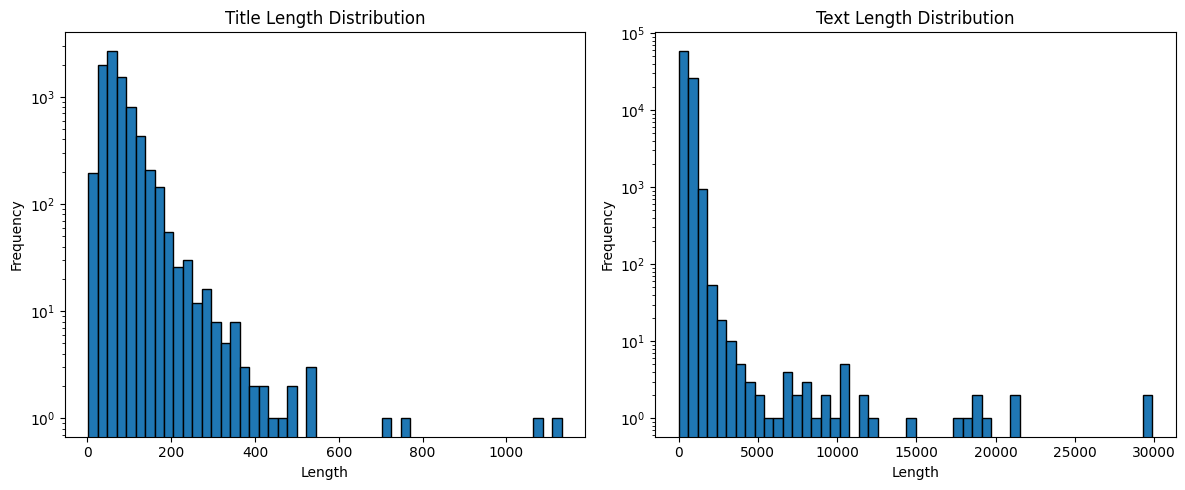

In [116]:
# Get unique nodes for titles
titles = pd.concat([df['TITLE_FROM'], df['TITLE_TO']]).dropna().unique()
title_lengths = pd.Series(titles).str.len()

# Get unique nodes for texts
texts = pd.concat([df['TEXT_FROM'], df['TEXT_TO']]).dropna().unique()
text_lengths = pd.Series(texts).str.len()

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(title_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Title Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.yscale("log")
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [117]:
# Create a table of statistics for title and text lengths
stats_data = {
    'Field': ['Title', 'Text'],
    'Mean': [
        title_lengths.mean(),
        text_lengths.mean()
    ],
    'Median': [
        title_lengths.median(),
        text_lengths.median()
    ],
    'Std Dev': [
        title_lengths.std(),
        text_lengths.std()
    ],
    'Min': [
        title_lengths.min(),
        text_lengths.min()
    ],
    'Max': [
        title_lengths.max(),
        text_lengths.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df.round(2))

,Field,Mean,Median,Std Dev,Min,Max
0,Title,73.05,62.0,46.82,2,1132
1,Text,538.17,496.0,357.01,10,29891


In [118]:
# Find celex with text length 8
for index, row in df[df["TEXT_FROM"].str.len() < 150].head(20).iterrows():
    print(row["TEXT_FROM"])
    print("-"*100)


In that respect it should be observed that, as the Court held in <CASE>, <PARAGRAPH>, <QUOTED_TEXT>.
----------------------------------------------------------------------------------------------------
In view of this context, the contested decision could be reasoned in a summary manner (<CASE>, <PARAGRAPH>, and <CASE>, <PARAGRAPH>).
----------------------------------------------------------------------------------------------------
First, measures of inquiry would necessarily lead to the Court ruling on questions of fact (see, to that effect, <CASE>, <PARAGRAPH>).
----------------------------------------------------------------------------------------------------
In that regard, it should be noted that the three conditions set out in that provision are cumulative (<CASE>, <PARAGRAPH>).
----------------------------------------------------------------------------------------------------
It must be remembered that in its judgments of <DATE> in <CASE>, <PARAGRAPH>, and <CASE>, <PARAGRAPH>

In [119]:
# Remove self_case_edges and temporal_violations
df = df[df["CELEX_FROM"] != df["CELEX_TO"]]
df = df[df["DATE_FROM"] >= df["DATE_TO"]]

In [121]:
# Export to excel
df.to_csv("data/clean_data.csv", index=False)